INICJALIZACJA I KONFIGURACJA

In [70]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import r2_score, mean_squared_error
from bayes_opt import BayesianOptimization
import pickle
import warnings

# Wyciszenie ewentualnych ostrzeżeń Pandas
warnings.filterwarnings('ignore')

# Ustawienie ziarna dla odtwarzalności i strefy czasowej na poziomie aplikacji
np.random.seed(123)
os.environ['TZ'] = 'UTC'

WYBÓR ZMIENNEJ OBJAŚNIANEJ, REGRESORÓW ORAZ INNYCH PARAMTERÓW

In [80]:
# ------------------------------------------------------------------------------
# WYBÓR ZMIENNEJ OBJAŚNIANEJ (zależnej)
# ------------------------------------------------------------------------------
zmienna_obj = "logATV"

# Parametry czasowe
Start_date = pd.to_datetime("2021-08-05").date()
last_update_date = pd.to_datetime("2026-06-09").date()
End_date = last_update_date - timedelta(days=1)
Start_prognozowanego_miesiaca = pd.to_datetime("2026-07-01").date()
End_pred = pd.to_datetime("2026-07-31").date()

nazwa_pliku_prognoza = "ATV_prognoza_2026_07.xlsx"

# Zmienne używane w modelu XGBoost
zmienne = [

    # eventy
    "Label",
    "Rank",
    "event_flag",
    "is_event_in_lags",

    # święta i kalendarz
    "Holiday",
    "Weekend",
    "PrimeTime",

    # czas podstawowy
    #"Hour_int",
    "Hour",
    "Daypart",
    #"Weekday_int",
    "Weekday",
    #"Month_int",
    "Month",
    #"Quarter_int",
    "Year_int",
    "Day_of_year",

    # sezonowość
    "Hour_sin",
    "Hour_cos",
    "Weekday_sin",
    "Weekday_cos",
    "Year_sin",
    "Year_cos",

    # słońce
    "Sunset",
    "Hours_after_sunset",
    "After_sunset",

    # trend
    "Trend",
    
    # pogoda
    "Temperatura maks.",
    "%Czas opadów",

    # lagi
    "Lag_1",
    "Lag_24",
    "Lag_48",
    "Lag_168",
    "Lag_336",
    "Lag_504",
    "Lag_672",
    "Lag_8760",

    # rolling
    "Roll_mean_24",
    "Roll_mean_168",
    "Roll_mean_336",
    
    # różnice sezonowe
    "Diff_24",
    "Diff_168",
    "Ratio_168"
]
# Ścieżki do plików
path_events = r"W:\Dzial Business process\Dzial Analiz\OSOBISTE\RAFAŁ\Wewnętrzne\Events_ratings.xlsx"
path_pogoda = r"C:\DanePYTHON\ATV\raport pogodowy - wykresy ATV.xlsx"


FUNKCJE POMOCNICZE


In [72]:
def parse_nielsen_datetime(df):
    df_out = df.copy()
    
    # 1. Konwersja wejściowej daty na datetime (bezpieczny start)
    df_out['Date'] = pd.to_datetime(df_out['Date']).dt.normalize()
    
    # 2. Wyciągnięcie HHMM z Daypart
    times_raw = df_out['Daypart'].astype(str).str.extract(r'(\d{4})', expand=False)
    
    # Czyszczenie z pustych wierszy
    valid_mask = times_raw.notna()
    df_out = df_out[valid_mask].copy()
    times_raw = times_raw[valid_mask]
    
    # 3. Przygotowanie formatu HH:MM:00
    time_strings = times_raw.str[:2] + ":" + times_raw.str[2:] + ":00"
    
    # 4. Obliczenie pełnego momentu w czasie (DT)
    # To tutaj "25:00" staje się "01:00" dnia następnego
    df_out['DT'] = df_out['Date'] + pd.to_timedelta(time_strings)
    
    # 5. AKTUALIZACJA KOLUMNY Date (Rzeczywista data kalendarzowa)
    # Wyciągamy datę z przeliczonego DT i rzutujemy na typ date
    df_out['Date'] = df_out['DT'].dt.date
    
    # 6. Kolumna Time (hms)
    df_out['Time'] = df_out['DT'].dt.strftime('%H:%M:%S')
    
    # 7. Lokalizacja strefy czasowej dla DT
    df_out['DT'] = df_out['DT'].dt.tz_localize('UTC')
    
    return df_out.drop(columns=['Daypart'])

def create_time_slices(n_samples, initial_window, horizon, skip):
    """
    Tworzy indeksy dla walidacji krzyżowej szeregów czasowych,
    z zachowaniem rosnącego okna 
    """
    folds = []
    train_end = initial_window
    while train_end + horizon <= n_samples:
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(train_end, train_end + horizon)
        folds.append((train_idx, test_idx))
        train_end += (skip + 1)
    return folds


Wgranie i processing danych

In [73]:
# =============================================================================
# PROCESSING DANYCH
# =============================================================================

print("Wczytywanie i processing danych...")


# =============================================================================
# 1. ATV
# =============================================================================

dane = (
    pd.read_csv(
        "Time ATV_hourly_TSV.csv",
        skiprows=10,
        decimal=","
    )
    .rename(columns={"TRP (avgW)": "ATV"})
)

dane = parse_nielsen_datetime(dane)

dane = (
    dane[["DT", "Date", "Time", "ATV"]]
    .sort_values("DT")
    .reset_index(drop=True)
)


# log1p zamiast log
dane["logATV"] = np.log1p(dane["ATV"])



# =============================================================================
# 2. EVENTS
# =============================================================================

Events_dane = pd.read_excel(
    path_events,
    sheet_name="Events_full"
)

Events_dane["DT"] = pd.to_datetime(
    Events_dane["DT"],
    utc=True
)

Events_dane["Duration"] = pd.to_timedelta(
    Events_dane["Duration"].astype(str)
)

Events_dane["End_DT"] = (
    Events_dane["DT"]
    + Events_dane["Duration"]
)

Events_dane = Events_dane.sort_values("DT")



# =============================================================================
# 3. HOLIDAY
# =============================================================================

Holiday_dane = pd.read_excel(
    path_events,
    sheet_name="Holiday_full"
)

Holiday_dane["Date"] = (
    pd.to_datetime(Holiday_dane["Data"])
    .dt.date
)

Holiday_dane = (
    Holiday_dane[["Date", "Holiday"]]
    .drop_duplicates()
)



# =============================================================================
# 4. DDT
# =============================================================================

DDT_dane = pd.read_excel(
    path_events,
    sheet_name="DDT"
)

DDT_dane["Date"] = (
    pd.to_datetime(DDT_dane["Date"])
    .dt.date
)

DDT_dane = DDT_dane.drop_duplicates()



# =============================================================================
# 5. POGODA
# =============================================================================

Pogoda_dane = pd.read_excel(path_pogoda)

Pogoda_dane["Date"] = (
    pd.to_datetime(Pogoda_dane["Data"])
    .dt.date
)

Pogoda_dane = (
    Pogoda_dane[
        [
            "Date",
            "Temperatura maks.",
            "%Czas opadów"
        ]
    ]
    .drop_duplicates()
)

Pogoda_dane["Temperatura maks."] = pd.to_numeric(
    Pogoda_dane["Temperatura maks."],
    errors="coerce"
)

Pogoda_dane["%Czas opadów"] = pd.to_numeric(
    Pogoda_dane["%Czas opadów"],
    errors="coerce"
)

# --- NOWOŚĆ: Wyliczenie średnich miesięcznych do późniejszej normalizacji ---
Pogoda_dane["Month_int"] = pd.to_datetime(Pogoda_dane["Date"]).dt.month
srednie_miesieczne_pogoda = (
    Pogoda_dane
    .groupby("Month_int")[["Temperatura maks.", "%Czas opadów"]]
    .mean()
    .reset_index()
    .rename(columns={
        "Temperatura maks.": "Temp_srednia_msc",
        "%Czas opadów": "Opady_srednia_msc"
    })
)


# =============================================================================
# EVENTY
# =============================================================================

dane = pd.merge_asof(
    dane,
    Events_dane[
        [
            "DT",
            "End_DT",
            "Label",
            "Rank"
        ]
    ],
    on="DT",
    direction="backward"
)

mask = dane["DT"] >= dane["End_DT"]

dane.loc[mask, ["Label", "Rank"]] = None

dane.drop(columns="End_DT", inplace=True)

dane["Label"] = dane["Label"].fillna("Brak")
dane["Rank"] = dane["Rank"].fillna(0)

dane["event_flag"] = (dane["Label"] != "Brak").astype(int)



# =============================================================================
# DANE DZIENNE
# =============================================================================

dane = dane.merge(
    Holiday_dane,
    on="Date",
    how="left"
)

dane["Holiday"] = dane["Holiday"].fillna("Brak")

dane = dane.merge(
    DDT_dane[["Date", "Sunset"]],
    on="Date",
    how="left"
)

dane = dane.merge(
    Pogoda_dane,
    on="Date",
    how="left"
)



# =============================================================================
# KALENDARZ
# =============================================================================

dane["Hour_int"] = dane["DT"].dt.hour
dane["Hour"] = dane["DT"].dt.hour.astype(str).str.zfill(2)
dane["Weekday_int"] = dane["DT"].dt.weekday
dane["Weekday"] = dane["DT"].dt.day_name()
dane["Month_int"] = dane["DT"].dt.month
dane["Month"] = dane["DT"].dt.month_name()
dane["Quarter_int"] = dane["DT"].dt.quarter
dane["Year_int"] = dane["DT"].dt.year
dane["Day_of_year"] = dane["DT"].dt.dayofyear
# Zmienna Daypart ---

time_minutes = dane["DT"].dt.hour * 60 + dane["DT"].dt.minute

dane["Daypart"] = np.select(
    [
        (time_minutes >= 6 * 60) & (time_minutes < 8 * 60 + 30),  # 6:00 - 8:29
        (time_minutes >= 8 * 60 + 30) & (time_minutes < 15 * 60), # 8:30 - 14:59
        (time_minutes >= 15 * 60) & (time_minutes < 17 * 60),     # 15:00 - 16:59
        (time_minutes >= 17 * 60) & (time_minutes < 23 * 60)      # 17:00 - 22:59
    ],
    [
        "Morning Time", 
        "Day Time", 
        "Early Fringe", 
        "Prime Time"
    ],
    default="Late Night" # Wszystko poza powyższymi ramami (czyli 23:00 - 5:59)
)
# sezonowość dobowa
dane["Hour_sin"] = np.sin(
    2*np.pi*dane["Hour_int"]/24
)

dane["Hour_cos"] = np.cos(
    2*np.pi*dane["Hour_int"]/24
)


# sezonowość tygodniowa
dane["Weekday_sin"] = np.sin(
    2*np.pi*dane["Weekday_int"]/7
)

dane["Weekday_cos"] = np.cos(
    2*np.pi*dane["Weekday_int"]/7
)


# sezonowość roczna
dane["Year_sin"] = np.sin(
    2*np.pi*dane["Day_of_year"]/365.25
)

# ... (tutaj kończy się oryginalny kod sezonowości rocznej z Year_cos) ...
dane["Year_cos"] = np.cos(
    2*np.pi*dane["Day_of_year"]/365.25
)

# --- NOWOŚĆ: Normalizacja danych historycznych (zamiana na odchylenia) ---
dane = dane.merge(srednie_miesieczne_pogoda, on="Month_int", how="left")
dane["Temperatura maks."] = dane["Temperatura maks."] - dane["Temp_srednia_msc"]
dane["%Czas opadów"] = dane["%Czas opadów"] - dane["Opady_srednia_msc"]

# Czyszczenie kolumn pomocniczych
dane.drop(columns=["Temp_srednia_msc", "Opady_srednia_msc"], inplace=True)



# =============================================================================
# PRIME TIME
# =============================================================================

dane["PrimeTime"] = (
    dane["Hour_int"]
    .between(17, 22)
    .astype(int)
)

dane["PrimeTimeNarrow"] = (
    dane["Hour_int"]
    .between(19, 21)
    .astype(int)
)

dane["Weekend"] = (
    dane["Weekday_int"] >= 5
).astype(int)



# =============================================================================
# ZACHÓD SŁOŃCA
# =============================================================================

dane["Sunset"] = (
    pd.to_timedelta(
        dane["Sunset"].astype(str),
        errors="coerce"
    )
    .dt.total_seconds()
    / 3600
)

dane["Hours_after_sunset"] = (
    dane["Hour_int"]
    - dane["Sunset"]
)

dane["After_sunset"] = (
    dane["Hours_after_sunset"] >= 0
).astype(int)



# =============================================================================
# TREND DŁUGOTERMINOWY
# =============================================================================

dane["Trend"] = np.arange(len(dane))
dane["Trend2"] = dane["Trend"] ** 2



# =============================================================================
# LAGI
# =============================================================================

lags = [
    1,2,3,6,12,
    24,48,72,
    168,336,504,672,
    8760
]

for lag in lags:
    dane[f"Lag_{lag}"] = (
        dane["ATV"]
        .shift(lag)
    )



# =============================================================================
# ROLLING
# =============================================================================

windows = [3,6,24,168,336, 672, 8760]

for w in windows:

    dane[f"Roll_mean_{w}"] = (
        dane["ATV"]
        .shift(1)
        .rolling(w)
        .mean()
    )

    dane[f"Roll_std_{w}"] = (
        dane["ATV"]
        .shift(1)
        .rolling(w)
        .std()
    )



# =============================================================================
# RÓŻNICE SEZONOWE
# =============================================================================

# POPRAWKA W DANYCH TRENINGOWYCH
dane["Diff_24"] = dane["Lag_1"] - dane["Lag_24"]
dane["Diff_168"] = dane["Lag_1"] - dane["Lag_168"]
dane["Ratio_168"] = dane["Lag_1"] / (dane["Lag_168"] + 1e-6)


# =============================================================================
# EVENTY W LAGACH
# =============================================================================

lags = [168,336,504,672]

dane["is_event_in_lags"] = (
    pd.concat(
        [
            dane["event_flag"].shift(x)
            for x in lags
        ],
        axis=1
    )
    .max(axis=1)
    .fillna(0)
    .astype(int)
)



# =============================================================================
# FINALIZACJA
# =============================================================================

End_date_parsed = pd.to_datetime(
    End_date
).date()

dane = (
    dane
    .sort_values("DT")
    .drop_duplicates(subset=["DT"])
    .loc[dane["DT"].dt.date <= End_date_parsed]
    .reset_index(drop=True)
)


Wczytywanie i processing danych...


MODELOWANIE XGBoost

In [74]:
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
from bayes_opt import BayesianOptimization
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

print("Przygotowywanie danych do modelowania...")

# =============================================================================
# 1. PRZYGOTOWANIE DANYCH
# =============================================================================

df_model = dane.copy()
df_model = df_model.dropna().reset_index(drop=True)

# TARGET
y = df_model["logATV"]

# FEATURES (zmienne objaśniające)
X = df_model[zmienne].copy()

# Usuwanie zmiennych docelowych i ID
cols_to_drop = ["DT", "logATV", "ATV"]
X = X.drop(columns=[c for c in cols_to_drop if c in X.columns], errors="ignore")


# =============================================================================
# 2. GLOBALNY FIX TYPÓW (KLUCZOWE DLA XGBOOST)
# =============================================================================
# Wykonujemy to RAZ dla całego zbioru X przed jakimkolwiek podziałem.
# Gwarantuje to ten sam zbiór kategorii dla train i test.

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].astype("category")

# Upewnienie się, że kategorie są czyste (str -> category)
cat_cols = X.select_dtypes(include=["category"]).columns
for col in cat_cols:
    X[col] = X[col].astype(str).astype("category")


# =============================================================================
# 3. SPLIT CZASOWY (NO LEAKAGE)
# =============================================================================

val_size = int(1.5 * 30 * 24)  # ~1080h

X_train = X.iloc[:-val_size].copy()
y_train = y.iloc[:-val_size].copy()

X_val = X.iloc[-val_size:].copy()
y_val = y.iloc[-val_size:].copy()

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru walidacyjnego: {X_val.shape}")


# =============================================================================
# 4. BAYESIAN OPTIMIZATION Z EARLY STOPPING
# =============================================================================


def xgb_evaluate(max_depth, learning_rate, n_estimators,
                 subsample, colsample_bytree, min_child_weight):
    
    # Inicjalizacja walidacji krzyżowej dla szeregów czasowych (np. 3 splity)
    tscv = TimeSeriesSplit(n_splits=3)
    rmse_scores = []
    
    # Pętla po foldach na zbiorze treningowym
    for train_index, val_index in tscv.split(X_train):
        X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
        # Inicjalizacja modelu dla pojedynczego foldu
        model = xgb.XGBRegressor(
            max_depth=int(max_depth),
            learning_rate=learning_rate,
            n_estimators=int(n_estimators),
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            enable_categorical=True,
            tree_method="hist",
            random_state=123,
            n_jobs=-1,
            early_stopping_rounds=20
        )

        # Trening z ewaluacją na kroczącym oknie walidacyjnym
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )
        
        # Pobieramy najlepszy wynik z danego foldu (dzięki early stopping)
        rmse_scores.append(model.best_score)
        
    # Zwracamy ujemną średnią RMSE ze wszystkich foldów (BO maksymalizuje wynik)
    return -np.mean(rmse_scores)

# Konfiguracja optymalizatora
xgb_bo = BayesianOptimization(
    f=xgb_evaluate,
    pbounds={
        "max_depth": (3, 10),
        "learning_rate": (0.01, 0.2),
        "n_estimators": (200, 1500), # Można dać więcej dzięki early stopping
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "min_child_weight": (1, 20)
    },
    random_state=123,
    verbose=2
)

print("\nRozpoczęcie optymalizacji bayesowskiej XGBoost...")
# Większa liczba iteracji dla lepszego zbadania przestrzeni (dzięki optymalizacji będzie szybciej)
xgb_bo.maximize(init_points=5, n_iter=20)

best_params = xgb_bo.max["params"]
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])

print("\nNajlepsze znalezione parametry:")
print(best_params)


# =============================================================================
# 5. WALIDACJA NA ZBIORZE TESTOWYM (CZYSTA OCENA)
# =============================================================================

# Trenujemy model ewaluacyjny TYLKO na zbiorze treningowym
eval_model = xgb.XGBRegressor(
    **best_params,
    enable_categorical=True,
    tree_method="hist",
    random_state=123,
    n_jobs=-1
)

eval_model.fit(X_train, y_train)
preds_val = eval_model.predict(X_val)

r2 = r2_score(y_val, preds_val)
rmse = np.sqrt(mean_squared_error(y_val, preds_val))

print("\nWyniki modelu na czystym zbiorze walidacyjnym (ostatnie ~1.5 miesiąca):")
print(f"R2  : {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


# =============================================================================
# 6. MODEL PRODUKCYJNY (OPCJONALNIE)
# =============================================================================
# Jeśli model idzie na produkcję do predykcji przyszłości, uczymy go na całości

print("\nTrenowanie ostatecznego modelu na pełnym zbiorze danych (do przyszłych predykcji)...")
final_model = xgb.XGBRegressor(
    **best_params,
    enable_categorical=True,
    tree_method="hist",
    random_state=123,
    n_jobs=-1
)

final_model.fit(X, y)

Przygotowywanie danych do modelowania...
Rozmiar zbioru treningowego: (37776, 40)
Rozmiar zbioru walidacyjnego: (1080, 40)

Rozpoczęcie optymalizacji bayesowskiej XGBoost...
|   iter    |  target   | max_depth | learni... | n_esti... | subsample | colsam... | min_ch... |
-------------------------------------------------------------------------------------------------
| 1         | -0.048655 | 7.8752842 | 0.0643664 | 494.90688 | 0.8205259 | 0.8877875 | 9.0390227 |
| 2         | -0.049842 | 9.8653493 | 0.1401176 | 825.21147 | 0.7568470 | 0.7372712 | 14.851944 |
| 3         | -0.047655 | 6.0700057 | 0.0213388 | 717.45753 | 0.8951981 | 0.6729966 | 4.3335833 |
| 4         | -0.049507 | 6.7208596 | 0.1110472 | 1024.7212 | 0.9397727 | 0.8897821 | 12.609446 |
| 5         | -0.048337 | 8.0571036 | 0.0713621 | 670.32525 | 0.6913052 | 0.7174856 | 12.988546 |
| 6         | -0.047887 | 5.3110267 | 0.0339258 | 716.98091 | 0.8712260 | 0.7888334 | 4.8904167 |
| 7         | -0.051144 | 10.0      | 0.2 

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.6729966921814)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.dataset

Processing danych do prognozy

In [75]:
# =============================================================================
# PRZYGOTOWANIE DANYCH DO PROGNOZY (DYNAMICZNY START)
# =============================================================================

print("Przygotowywanie ramki danych dla okresu prognozy...")

# -----------------------------------------------------------------------------
# 1. TWORZENIE SIATKI GODZINOWEJ DLA PROGNOZY
# -----------------------------------------------------------------------------

# Dynamiczny start: dokładnie jedna godzina po ostatniej obserwacji w historii
start_prognozy = dane['DT'].max() + pd.Timedelta(hours=1)
end_prognozy = (pd.to_datetime(End_pred) + pd.Timedelta(hours=23)).tz_localize('UTC')
pred_range = pd.date_range(
    start=start_prognozy,
    end=end_prognozy,
    freq='H'
)

df_pred = pd.DataFrame({'DT': pred_range})
df_pred['Date'] = df_pred['DT'].dt.date
df_pred['Time'] = df_pred['DT'].dt.strftime('%H:%M:%S')

# ATV i logATV → NaN (to prognozujemy w pętli)
df_pred['ATV'] = np.nan
df_pred['logATV'] = np.nan

# -----------------------------------------------------------------------------
# 2. EVENTY (merge_asof jak w danych historycznych)
# -----------------------------------------------------------------------------

# Filtrujemy eventy, które kończą się po starcie naszej prognozy
Events_pred = Events_dane[
    (Events_dane['End_DT'] >= start_prognozy)
].copy()

if not Events_pred.empty:
    df_pred = pd.merge_asof(
        df_pred.sort_values('DT'),
        Events_pred[['DT', 'End_DT', 'Label', 'Rank']].sort_values('DT'),
        on='DT',
        direction='backward'
    )
    
    # Wyzeruj eventy, które już się skończyły
    mask = df_pred['DT'] >= df_pred['End_DT']
    df_pred.loc[mask, ['Label', 'Rank']] = None
    df_pred.drop(columns='End_DT', inplace=True, errors='ignore')
else:
    df_pred['Label'] = None
    df_pred['Rank'] = None

df_pred['Label'] = df_pred['Label'].fillna('Brak')
df_pred['Rank'] = df_pred['Rank'].fillna(0)
df_pred['event_flag'] = (df_pred['Label'] != 'Brak').astype(int)

# -----------------------------------------------------------------------------
# 3. ŚWIĘTA (HOLIDAY)
# -----------------------------------------------------------------------------

df_pred = df_pred.merge(
    Holiday_dane,
    on='Date',
    how='left'
)
df_pred['Holiday'] = df_pred['Holiday'].fillna('Brak')

# -----------------------------------------------------------------------------
# 4. ZACHÓD SŁOŃCA (DDT)
# -----------------------------------------------------------------------------

df_pred = df_pred.merge(
    DDT_dane[['Date', 'Sunset']],
    on='Date',
    how='left'
)

df_pred['Sunset'] = (
    pd.to_timedelta(df_pred['Sunset'].astype(str), errors='coerce')
    .dt.total_seconds() / 3600
)

# -----------------------------------------------------------------------------
# 5. POGODA → DYNAMICZNA ŚREDNIA MIESIĘCZNA Z HISTORII (TRANSFORMACJA NA ODCHYLENIE)
# -----------------------------------------------------------------------------

# Przypisujemy numer miesiąca do df_pred na potrzeby złączenia pogody
df_pred['Month_int'] = df_pred['DT'].dt.month

# Łączymy ramkę prognozy z profilami średnich
df_pred = df_pred.merge(srednie_miesieczne_pogoda, on='Month_int', how='left')

# Obliczamy odchylenie: (Wartość prognozy pogody) - (Średnia dla tego miesiąca)
# Ponieważ jako bazową pogodę na przyszłość przyjmujesz średnią historyczną, 
# odchylenie wyniesie tu 0. Kod jest jednak uniwersalny (nie popsuje się po wskazaniu realnej prognozy).
df_pred['Temperatura maks.'] = df_pred['Temp_srednia_msc'] - df_pred['Temp_srednia_msc']
df_pred['%Czas opadów'] = df_pred['Opady_srednia_msc'] - df_pred['Opady_srednia_msc']

# Usuwamy pomocnicze kolumny średnich, zostawiając czyste odchylenia pod oryginalnymi nazwami
df_pred.drop(columns=['Temp_srednia_msc', 'Opady_srednia_msc'], inplace=True)
# -----------------------------------------------------------------------------
# 6. KALENDARZ
# -----------------------------------------------------------------------------

df_pred['Hour_int'] = df_pred['DT'].dt.hour
df_pred['Hour'] = df_pred['DT'].dt.hour.astype(str).str.zfill(2)
df_pred['Weekday_int'] = df_pred['DT'].dt.weekday
df_pred['Weekday'] = df_pred['DT'].dt.day_name()
df_pred['Month_int'] = df_pred['DT'].dt.month
df_pred['Month'] = df_pred['DT'].dt.month_name()
df_pred['Quarter_int'] = df_pred['DT'].dt.quarter
df_pred['Year_int'] = df_pred['DT'].dt.year
df_pred['Day_of_year'] = df_pred['DT'].dt.dayofyear

# --- NOWOŚĆ: Zmienna Daypart w prognozie ---
time_minutes_pred = df_pred["DT"].dt.hour * 60 + df_pred["DT"].dt.minute

df_pred["Daypart"] = np.select(
    [
        (time_minutes_pred >= 6 * 60) & (time_minutes_pred < 8 * 60 + 30),
        (time_minutes_pred >= 8 * 60 + 30) & (time_minutes_pred < 15 * 60),
        (time_minutes_pred >= 15 * 60) & (time_minutes_pred < 17 * 60),
        (time_minutes_pred >= 17 * 60) & (time_minutes_pred < 23 * 60)
    ],
    [
        "Morning Time", 
        "Day Time", 
        "Early Fringe", 
        "Prime Time"
    ],
    default="Late Night"
)

# Sezonowość dobowa
df_pred['Hour_sin'] = np.sin(2 * np.pi * df_pred['Hour_int'] / 24)
df_pred['Hour_cos'] = np.cos(2 * np.pi * df_pred['Hour_int'] / 24)

# Sezonowość tygodniowa
df_pred['Weekday_sin'] = np.sin(2 * np.pi * df_pred['Weekday_int'] / 7)
df_pred['Weekday_cos'] = np.cos(2 * np.pi * df_pred['Weekday_int'] / 7)

# Sezonowość roczna
df_pred['Year_sin'] = np.sin(2 * np.pi * df_pred['Day_of_year'] / 365.25)
df_pred['Year_cos'] = np.cos(2 * np.pi * df_pred['Day_of_year'] / 365.25)

# -----------------------------------------------------------------------------
# 7. PRIME TIME / WEEKEND
# -----------------------------------------------------------------------------

df_pred['PrimeTime'] = df_pred['Hour_int'].between(17, 22).astype(int)  # Powrót do zakresu 17-22 z definicji treningowej
df_pred['Weekend'] = (df_pred['Weekday_int'] >= 5).astype(int)

# -----------------------------------------------------------------------------
# 8. ZACHÓD SŁOŃCA - FEATURES
# -----------------------------------------------------------------------------

df_pred['Hours_after_sunset'] = df_pred['Hour_int'] - df_pred['Sunset']
df_pred['After_sunset'] = (df_pred['Hours_after_sunset'] >= 0).astype(int)

# -----------------------------------------------------------------------------
# 9. TREND (kontynuacja z danych historycznych)
# -----------------------------------------------------------------------------

last_trend = dane['Trend'].iloc[-1]
df_pred['Trend'] = np.arange(len(df_pred)) + last_trend + 1
df_pred['Trend2'] = df_pred['Trend'] ** 2

Przygotowywanie ramki danych dla okresu prognozy...


Prognoza iteracyjna

In [76]:
import time

# =============================================================================
# ITERACYJNE PROGNOZOWANIE Z MODELU XGBOOST (AUTOREGRESJA)
# =============================================================================

print("\nRozpoczęcie iteracyjnego prognozowania krok po kroku...")
start_time = time.time()

# 1. Połączenie zbioru historycznego i siatki predykcyjnej
# Ograniczamy historię tylko do wymaganego maksimum, aby zoptymalizować RAM i prędkość pętli.
# Największy lag/okno to 8760 godzin (rok).
max_history_needed = 8760
df_hist = dane.tail(max_history_needed).copy()

# Sklejenie danych historycznych z ramką przygotowaną pod prognozy
df_combined = pd.concat([df_hist, df_pred], ignore_index=True)

# Indeksy określające zakres, gdzie brakuje ATV (gdzie zaczyna się df_pred)
start_idx = len(df_hist)
end_idx = len(df_combined)

# Zabezpieczenie kategorii: XGBoost jest restrykcyjny co do Dtype-ów.
# Narzucamy dokładnie te same kategorie co w zbiorze treningowym (X).
cat_cols = X.select_dtypes(include=["category"]).columns
for col in cat_cols:
    if col in df_combined.columns:
        # Przypisujemy konkretny obiekt Categorical z definicją z obiektu X
        df_combined[col] = pd.Categorical(
            df_combined[col].astype(str), 
            categories=X[col].cat.categories
        )

# Listy parametrów czasowych (zgodne z poprzednim kodem)
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336, 504, 672, 8760]
windows = [3, 6, 24, 168, 336, 672, 8760]
event_lags = [168, 336, 504, 672]

# 2. Główna pętla prognozująca (wypełnianie NaN wiersz po wierszu)
for i in range(start_idx, end_idx):
    
    # a) Przeliczenie Lagów 
    for lag in lags:
        df_combined.loc[i, f"Lag_{lag}"] = df_combined.loc[i - lag, "ATV"]
        
    # b) Przeliczenie Rolling Windows (średnia i odchylenie)
    # Wykorzystujemy zachowanie indeksu: .loc[start:end] w pandas zamyka przedział obustronnie!
    for w in windows:
        window_slice = df_combined.loc[i - w : i - 1, "ATV"]
        df_combined.loc[i, f"Roll_mean_{w}"] = window_slice.mean()
        df_combined.loc[i, f"Roll_std_{w}"] = window_slice.std()
        
    # c) Przeliczenie różnic i wskaźników sezonowych
    lag_1 = df_combined.loc[i, "Lag_1"]
    df_combined.loc[i, "Diff_24"] = lag_1 - df_combined.loc[i, "Lag_24"]
    df_combined.loc[i, "Diff_168"] = lag_1 - df_combined.loc[i, "Lag_168"]
    df_combined.loc[i, "Ratio_168"] = lag_1 / (df_combined.loc[i, "Lag_168"] + 1e-6)
    
    # d) Eventy w lagach (czy był event w konkretnych przesunięciach)
    event_flags_in_lags = [df_combined.loc[i - x, "event_flag"] for x in event_lags]
    df_combined.loc[i, "is_event_in_lags"] = int(max(event_flags_in_lags))
    
    # e) Wyselekcjonowanie wiersza dla modelu (zgodnie z ułożeniem zmiennych w 'zmienne')
    X_i = df_combined.loc[[i], zmienne].copy()
    
    # f) Predykcja logATV
    pred_log_atv = final_model.predict(X_i)[0]
    
    # g) Zapisanie wyniku do ramki - i transformacja odwrotna (log1p -> expm1) dla ATV
    df_combined.loc[i, "logATV"] = pred_log_atv
    df_combined.loc[i, "ATV"] = np.expm1(pred_log_atv)




Rozpoczęcie iteracyjnego prognozowania krok po kroku...


ATV na następny miesiąc

In [78]:
# =============================================================================
# ATV NA NASTĘPNY MIESIĄC
# =============================================================================

# pełna prognoza (bez filtrowania po dacie)
prognoza = df_combined.loc[start_idx:].copy()

# kolumna pomocnicza
prognoza["ATV_predykcja"] = prognoza["ATV"]

# maska tylko dla okresu raportowego (miesiąc prognozy)
mask_miesiac = (
    (prognoza["Date"] >= Start_prognozowanego_miesiaca) &
    (prognoza["Date"] <= End_pred)
)

# średnia tylko dla wybranego okresu
srednia_atv = prognoza.loc[mask_miesiac, "ATV"].mean()

# --- NOWOŚĆ: Wyświetlenie błędu RMSE modelu przed wynikami prognozy ---
print("=" * 60)
print(f"Jakość dopasowania modelu (RMSE walidacyjny): {rmse:.4f}")
print("-" * 60)

print(
    f"Średnia ATV w okresie {Start_prognozowanego_miesiaca} - {End_pred}: "
    f"{srednia_atv:.2f}"
)
print("=" * 60)

# jeśli chcesz dalej eksportować tylko miesiąc – twórz osobną ramkę
prognoza_miesiac = prognoza.loc[mask_miesiac].copy()

# przywrócenie kolejności kolumn
kolumny_docelowe = (
    ["DT", "Date", "Time", "ATV", "logATV", "ATV_predykcja"]
    + [c for c in zmienne if c not in ["DT", "Date", "Time", "ATV", "logATV"]]
)

prognoza = prognoza[kolumny_docelowe]

# usunięcie tz przed zapisem do Excel
if pd.api.types.is_datetime64tz_dtype(prognoza["DT"]):
    prognoza["DT"] = prognoza["DT"].dt.tz_localize(None)

prognoza.to_excel(nazwa_pliku_prognoza, index=False)

Jakość dopasowania modelu (RMSE walidacyjny): 0.0832
------------------------------------------------------------
Średnia ATV w okresie 2026-07-01 - 2026-07-31: 11.80


Tabela fitted vs actual values

In [ ]:
# =============================================================================
# TABELA FITTED VS ACTUAL
# =============================================================================

df_fit = df_model.copy()

# predykcja na zbiorze historycznym
pred_log = final_model.predict(X)
pred_atv = np.expm1(pred_log)

df_fit["ATV_predykcja"] = pred_atv

# residuals
df_fit["Residuals"] = (
    df_fit["ATV"] - df_fit["ATV_predykcja"]
)

df_fit["Residuals^2"] = (
    df_fit["Residuals"] ** 2
)

tabela_fit = df_fit[
    [
        "DT",
        "Holiday",
        "Label",
        "Rank",
        "Temperatura maks.",
        "%Czas opadów",
        "ATV",
        "ATV_predykcja",
        "Residuals",
        "Residuals^2"
    ]
].copy()

print(tabela_fit.head())

                         DT   Holiday Label  Rank  Temperatura maks.  \
0 2022-01-01 02:00:00+00:00  Nowy Rok  Brak   0.0           7.458817   
1 2022-01-01 03:00:00+00:00  Nowy Rok  Brak   0.0           7.458817   
2 2022-01-01 04:00:00+00:00  Nowy Rok  Brak   0.0           7.458817   
3 2022-01-01 05:00:00+00:00  Nowy Rok  Brak   0.0           7.458817   
4 2022-01-01 06:00:00+00:00  Nowy Rok  Brak   0.0           7.458817   

   %Czas opadów     ATV  ATV_predykcja  Residuals  Residuals^2  
0      0.078089  12.407      12.360133   0.046867     0.002196  
1      0.078089   7.361       7.460667  -0.099667     0.009933  
2      0.078089   4.772       4.777052  -0.005052     0.000026  
3      0.078089   2.810       2.882744  -0.072744     0.005292  
4      0.078089   2.554       2.509625   0.044375     0.001969  


Wykres fitted vs actual values

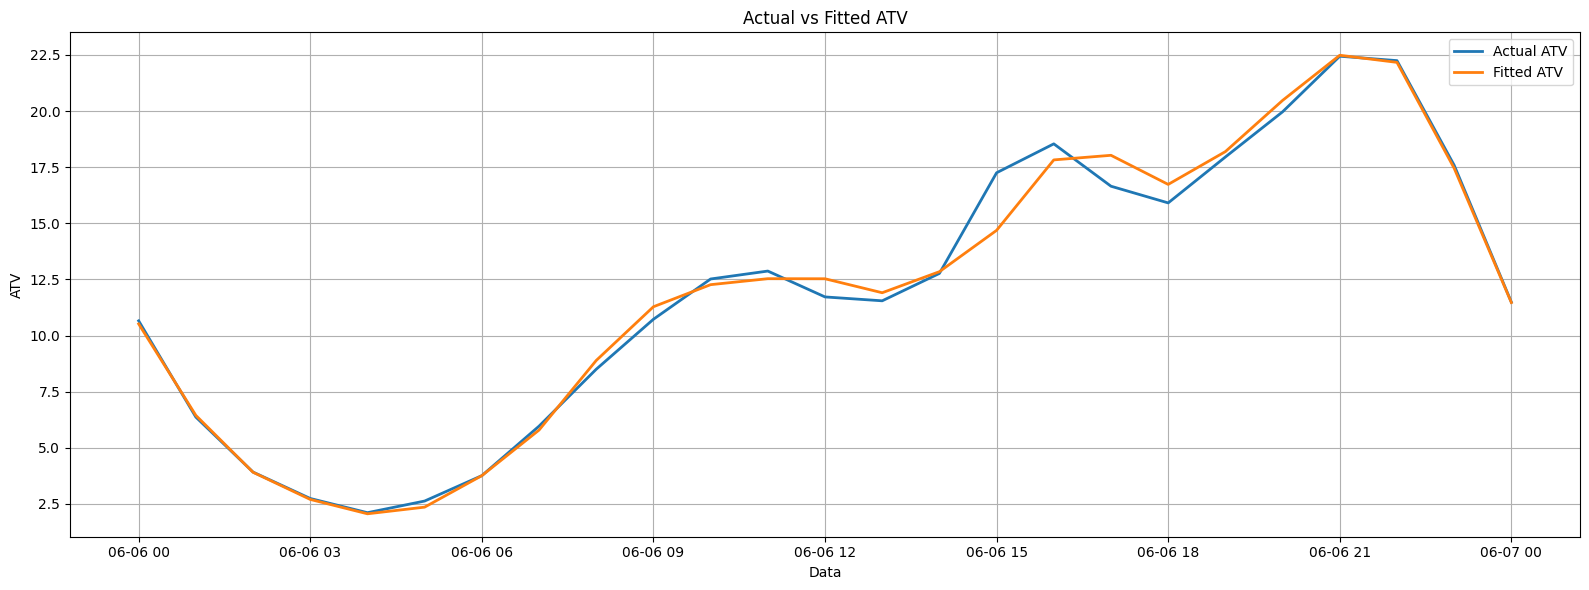

In [79]:
# =============================================================================
# WYKRES FITTED VS ACTUAL
# =============================================================================
data_od = "2026-06-06"
data_do = "2026-06-07"

plot_df = tabela_fit.loc[
    (tabela_fit["DT"] >= data_od) &
    (tabela_fit["DT"] <= data_do)
].copy()

plt.figure(figsize=(16, 6))

plt.plot(
    plot_df["DT"],
    plot_df["ATV"],
    label="Actual ATV",
    linewidth=2
)

plt.plot(
    plot_df["DT"],
    plot_df["ATV_predykcja"],
    label="Fitted ATV",
    linewidth=2
)

plt.title("Actual vs Fitted ATV")
plt.xlabel("Data")
plt.ylabel("ATV")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Wykres prognozowanych wartości

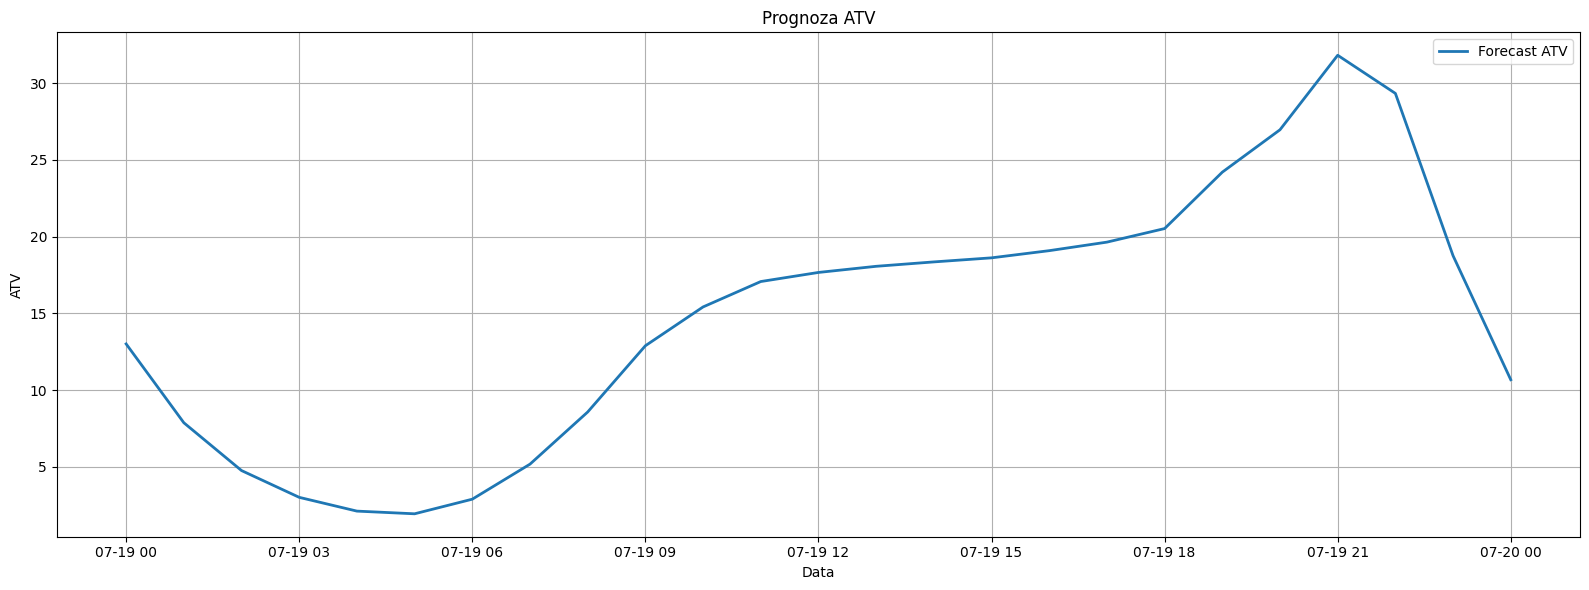

In [ ]:
prog_od = "2026-07-19"
prog_do = "2026-07-20"

# filtr dat
plot_forecast = prognoza.loc[
    (prognoza["DT"] >= prog_od) &
    (prognoza["DT"] <= prog_do)
].copy()

# znajdź kolumnę z ATV (bez zgadywania na sztywno)
atv_cols = [c for c in plot_forecast.columns if "ATV" in c]

if len(atv_cols) == 0:
    raise ValueError(f"Brak kolumny ATV w danych. Dostępne kolumny: {list(plot_forecast.columns)}")

# wybierz pierwszą pasującą kolumnę
y_col = atv_cols[0]

plt.figure(figsize=(16, 6))

plt.plot(
    plot_forecast["DT"],
    plot_forecast[y_col],
    linewidth=2,
    label=f"Forecast {y_col}"
)

plt.title("Prognoza ATV")
plt.xlabel("Data")
plt.ylabel("ATV")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()